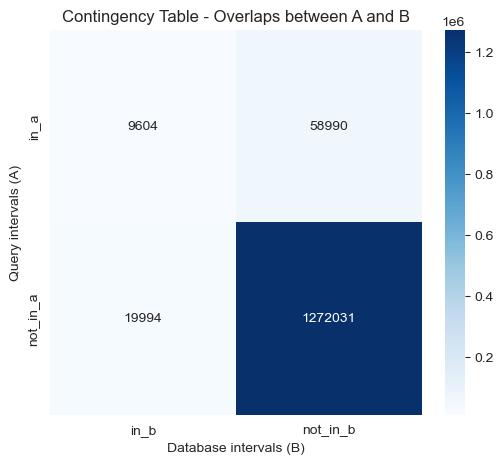

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = r"D:\SYSTEMS BIOLOGY\fisher_results.txt"

# Leggi tutte le righe
with open(file_path) as f:
    lines = f.readlines()

# Trova l'inizio della tabella
table_start = None
for i, line in enumerate(lines):
    if "in -b" in line and "not in -b" in line:
        table_start = i + 1
        break

# Leggi solo le righe che contengono numeri
data_rows = []
for r in lines[table_start:table_start+2]:  # 2 righe della contingency table
    # prendi solo le parti che sono numeri
    nums = [int(x) for x in r.strip().split() if x.isdigit()]
    data_rows.append(nums)

# Creo il DataFrame
data = pd.DataFrame(data_rows, columns=["in_b", "not_in_b"], index=["in_a", "not_in_a"])

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(data, annot=True, fmt="d", cmap="Blues")
plt.title("Contingency Table - Overlaps between A and B")
plt.ylabel("Query intervals (A)")
plt.xlabel("Database intervals (B)")
plt.show()


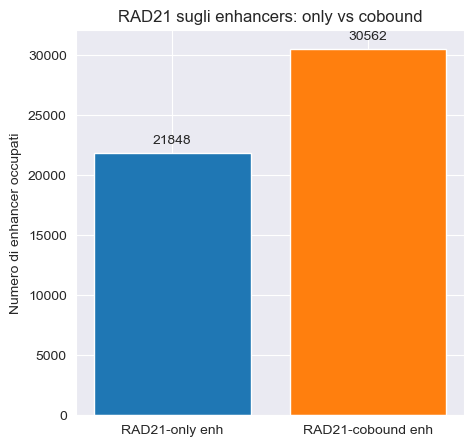

In [30]:
import matplotlib.pyplot as plt

only = 21848
cobound = 30562

plt.figure(figsize=(5,5))
plt.bar(["RAD21-only enh", "RAD21-cobound enh"], [only, cobound], color=["#1f77b4","#ff7f0e"])
plt.ylabel("Numero di enhancer occupati")
plt.title("RAD21 sugli enhancers: only vs cobound")

# Aggiungi i valori sopra le barre
for i, v in enumerate([only, cobound]):
    plt.text(i, v+500, str(v), ha='center', va='bottom')

plt.show()


C:\Users\imada\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


  Comparison  OddsRatio  Pvalue  logP    log2OR
0  promoters     10.358     0.0   inf  3.372674
1  enhancers     18.154     0.0   inf  4.182216
2       CTCF    622.057     0.0   inf  9.280903
3        PLS     19.907     0.0   inf  4.315204
4       dELS      9.633     0.0   inf  3.267985
5       pELS      8.624     0.0   inf  3.108357


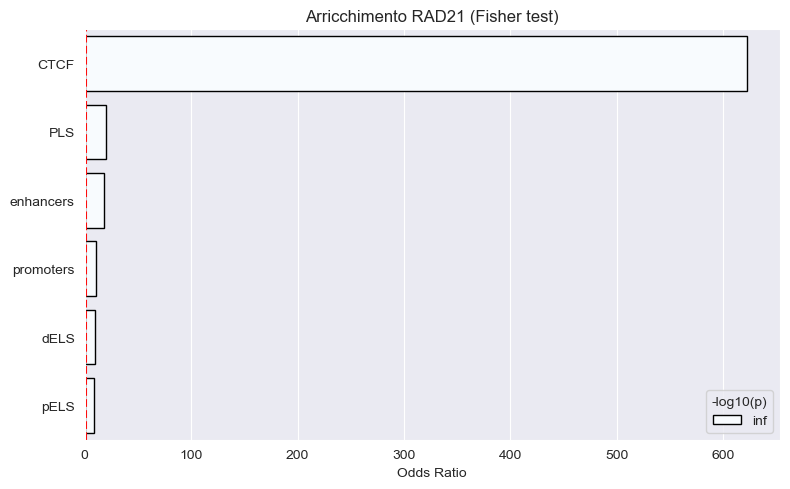

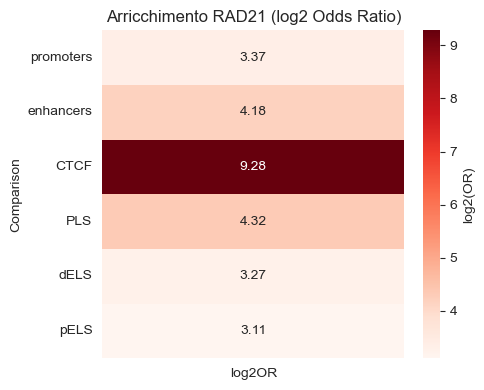

In [16]:
import os
os.chdir(r"D:\SYSTEMS BIOLOGY")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Elenco file Fisher (adatta i percorsi)
files = {
    "promoters": "fisher_RAD21_vs_promoters.txt",
    "enhancers": "fisher_RAD21_vs_enhancers.txt",
    "CTCF": "fisher_RAD21_vs_CTCF_clean.txt",
    "PLS": "fisher_RAD21_vs_PLS.txt",
    "dELS": "fisher_RAD21_vs_dELS.txt",
    "pELS": "fisher_RAD21_vs_pELS.txt"
}

# --- 2. Leggi i file Fisher
df_list = []
for name, path in files.items():
    try:
        tab = pd.read_csv(path, sep="\t", comment="#")
        if "ratio" in tab.columns and "two-tail" in tab.columns:
            odds = float(tab["ratio"].iloc[0])
            pval = float(tab["two-tail"].iloc[0])
            df_list.append({"Comparison": name, "OddsRatio": odds, "Pvalue": pval})
    except Exception as e:
        print(f"Errore con {name}: {e}")

df = pd.DataFrame(df_list)
df["logP"] = -np.log10(df["Pvalue"])
df["log2OR"] = np.log2(df["OddsRatio"])

print(df)

# --- 3. Barplot colorato
plt.figure(figsize=(8,5))
sns.barplot(data=df.sort_values("OddsRatio", ascending=False),
            x="OddsRatio", y="Comparison", hue="logP", dodge=False,
            palette="Blues", edgecolor="black",)
plt.axvline(1, ls="--", color="red")
plt.title("Arricchimento RAD21 (Fisher test)")
plt.xlabel("Odds Ratio")
plt.ylabel("")
plt.legend(title="-log10(p)", loc="lower right")
plt.tight_layout()
plt.show()

# --- 4. Heatmap log2(OR)
plt.figure(figsize=(5,4))
sns.heatmap(df.set_index("Comparison")[["log2OR"]],
            annot=True, fmt=".2f", cmap="Reds",
            cbar_kws={'label': 'log2(OR)'})
plt.title("Arricchimento RAD21 (log2 Odds Ratio)")
plt.tight_layout()

plt.show()



C:\Users\imada\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


  Comparison  OddsRatio  Pvalue  logP    log2OR
0  promoters     10.358     0.0   inf  3.372674
1  enhancers     18.154     0.0   inf  4.182216
2       dELS      9.633     0.0   inf  3.267985
3       pELS      8.624     0.0   inf  3.108357


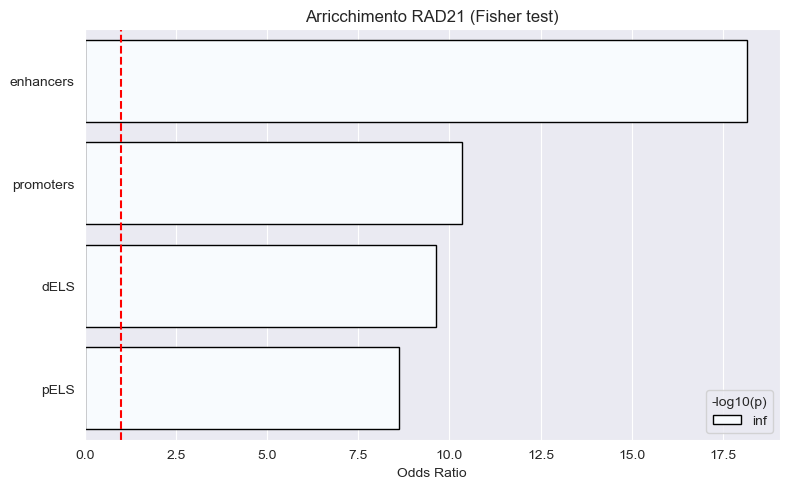

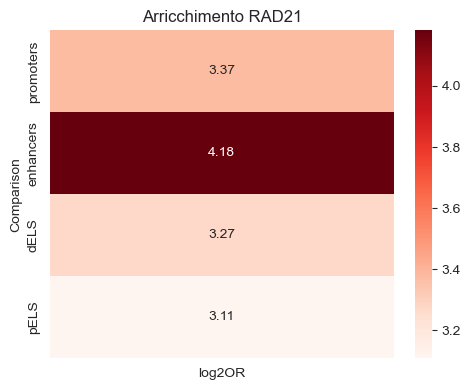

Comparison        Pvalue
 promoters 1.000000e-300
 enhancers 1.000000e-300
      dELS 1.000000e-300
      pELS 1.000000e-300


In [22]:
files = {
    "promoters": "fisher_RAD21_vs_promoters.txt",
    "enhancers": "fisher_RAD21_vs_enhancers.txt",

    "dELS": "fisher_RAD21_vs_dELS.txt",
    "pELS": "fisher_RAD21_vs_pELS.txt"
}

# --- 2. Leggi i file Fisher
df_list = []
for name, path in files.items():
    try:
        tab = pd.read_csv(path, sep="\t", comment="#")
        if "ratio" in tab.columns and "two-tail" in tab.columns:
            odds = float(tab["ratio"].iloc[0])
            pval = float(tab["two-tail"].iloc[0])
            df_list.append({"Comparison": name, "OddsRatio": odds, "Pvalue": pval})
    except Exception as e:
        print(f"Errore con {name}: {e}")

df = pd.DataFrame(df_list)
df["logP"] = -np.log10(df["Pvalue"])
df["log2OR"] = np.log2(df["OddsRatio"])

print(df)

# --- 3. Barplot colorato
plt.figure(figsize=(8,5))
sns.barplot(data=df.sort_values("OddsRatio", ascending=False),
            x="OddsRatio", y="Comparison", hue="logP", dodge=False,
            palette="Blues", edgecolor="black",)
plt.axvline(1, ls="--", color="red")
plt.title("Arricchimento RAD21 (Fisher test)")
plt.xlabel("Odds Ratio")
plt.ylabel("")
plt.legend(title="-log10(p)", loc="lower right")
plt.tight_layout()
plt.show()

# --- 4. Heatmap log2(OR)
plt.figure(figsize=(5,4))
sns.heatmap(df.set_index("Comparison")[["log2OR"]],
            annot=True, fmt=".2f", cmap="Reds",
            )
plt.title("Arricchimento RAD21")
plt.tight_layout()

plt.show()

pvals = []
for name, path in files.items():
    try:
        tab = pd.read_csv(path, sep="\t", comment="#")
        if "two-tail" in tab.columns:
            pval = float(tab["two-tail"].iloc[0])
            if pval == 0:   # evita lo zero assoluto
                pval = 1e-300
            pvals.append({"Comparison": name, "Pvalue": pval})
    except Exception as e:
        print(f"Errore con {name}: {e}")

# --- 4. Tabella finale
df = pd.DataFrame(pvals).sort_values("Pvalue")
print(df.to_string(index=False))


CSV pulito creato in: D:\SYSTEMS BIOLOGY\fisher_results_clean.csv
          DB_in  DB_not_in
Query_in   9604      58990
Query_in  19994    1272031


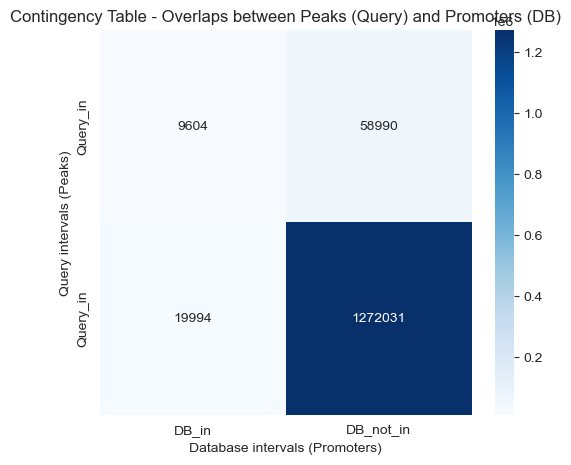

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Percorso del file originale
file_path = r"D:\SYSTEMS BIOLOGY\fisher_results.txt"

# Percorso del file CSV pulito da creare
csv_output = r"D:\SYSTEMS BIOLOGY\fisher_results_clean.csv"

# Leggi tutte le righe
with open(file_path) as f:
    lines = f.readlines()

# Trova l'inizio della contingency table
table_start = None
for i, line in enumerate(lines):
    if "in -b" in line and "not in -b" in line:
        table_start = i + 1
        break

if table_start is None:
    raise ValueError("Non è stata trovata la tabella nel file.")

# Estrai solo le righe con numeri (2 righe)
data_rows = []
row_names = []
for r in lines[table_start:table_start+2]:
    parts = r.strip().split()
    # Estrai solo i numeri
    nums = [int(x) for x in parts if x.isdigit()]
    if len(nums) != 2:
        raise ValueError(f"Riga non valida: {r}")
    data_rows.append(nums)
    # Nomi chiari per le righe
    if "in -a" in r:
        row_names.append("Query_in")
    else:
        row_names.append("Query_not_in")

# Crea DataFrame pulito
df = pd.DataFrame(data_rows, columns=["DB_in", "DB_not_in"], index=row_names)

# Salva in CSV
df.to_csv(csv_output)
print(f"CSV pulito creato in: {csv_output}")
print(df)

# --- Genera heatmap ---
plt.figure(figsize=(6,5))
sns.heatmap(df, annot=True, fmt="d", cmap="Blues")
plt.title("Contingency Table - Overlaps between Peaks (Query) and Promoters (DB)")
plt.ylabel("Query intervals (Peaks)")
plt.xlabel("Database intervals (Promoters)")
plt.show()


Errore con cobound_pELS: [Errno 2] No such file or directory: 'fisher_cobound_vs_pELS.txt'
Errore con only_pELS: [Errno 2] No such file or directory: 'fisher_only_vs_pELS.txt'
Errore con cobound_dELS: [Errno 2] No such file or directory: 'fisher_cobound_vs_dELS.txt'
Errore con only_dELS: [Errno 2] No such file or directory: 'fisher_only_vs_dELS.txt'


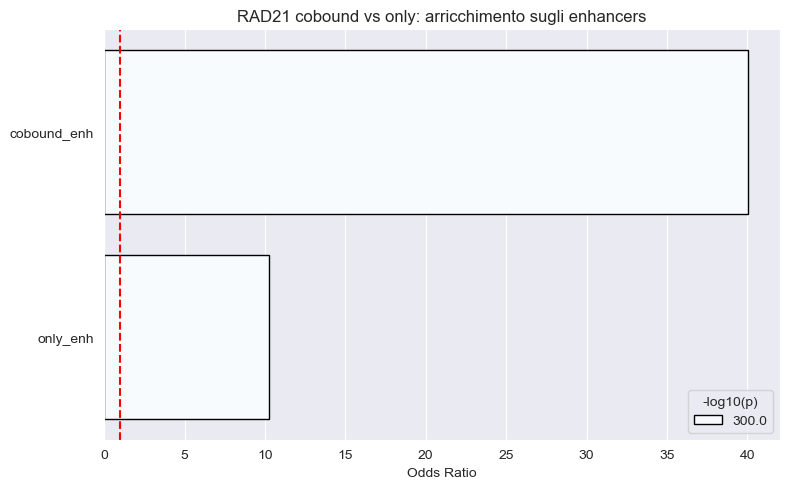

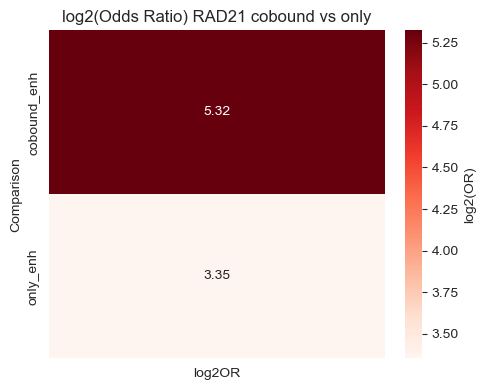

In [24]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Vai nella cartella
os.chdir(r"D:\SYSTEMS BIOLOGY")

# 2) File di interesse
files = {
    "cobound_enh": "fisher_cobound_vs_enh.txt",
    "only_enh":    "fisher_only_vs_enh.txt",
    "cobound_pELS":"fisher_cobound_vs_pELS.txt",
    "only_pELS":   "fisher_only_vs_pELS.txt",
    "cobound_dELS":"fisher_cobound_vs_dELS.txt",
    "only_dELS":   "fisher_only_vs_dELS.txt"
}

# 3) Leggi file ed estrai ratio e p-value
df_list = []
for name, path in files.items():
    try:
        tab = pd.read_csv(path, sep="\t", comment="#")
        if {"ratio","two-tail"}.issubset(tab.columns):
            OR = float(tab["ratio"].iloc[0])
            pval = float(tab["two-tail"].iloc[0])
            if pval == 0.0:  # evita inf
                pval = 1e-300
            df_list.append({
                "Comparison": name,
                "OddsRatio": OR,
                "log2OR": np.log2(OR),
                "Pvalue": pval,
                "-log10P": -np.log10(pval)
            })
    except Exception as e:
        print(f"Errore con {name}: {e}")

df = pd.DataFrame(df_list)

# 4) Barplot comparativo
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="OddsRatio", y="Comparison", hue="-log10P",
            dodge=False, palette="Blues", edgecolor="black")
plt.axvline(1, ls="--", color="red")
plt.title("RAD21 cobound vs only: arricchimento sugli enhancers")
plt.xlabel("Odds Ratio")
plt.ylabel("")
plt.legend(title="-log10(p)")
plt.tight_layout()
plt.show()

# 5) Heatmap log2(OR)
plt.figure(figsize=(5,4))
sns.heatmap(df.set_index("Comparison")[["log2OR"]],
            annot=True, fmt=".2f", cmap="Reds",
            cbar_kws={'label': 'log2(OR)'})
plt.title("log2(Odds Ratio) RAD21 cobound vs only")
plt.tight_layout()
plt.show()

# 6) Salva tabella riassuntiva
df.to_csv("rad21_cobound_only_enhancer_summary.csv", index=False)


In [27]:
!pip install pybedtools

     ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.6 MB 1.3 MB/s eta 0:00:10
     ---------------------------------------- 0.0/12.6 MB 1.3 MB/s eta 0:00:10
     --------------------------------------- 0.0/12.6 MB 245.8 kB/s eta 0:00:52
     --------------------------------------- 0.1/12.6 MB 363.1 kB/s eta 0:00:35
     --------------------------------------- 0.2/12.6 MB 706.2 kB/s eta 0:00:18
      -------------------------------------- 0.2/12.6 MB 831.5 kB/s eta 0:00:15
      -------------------------------------- 0.2/12.6 MB 758.5 kB/s eta 0:00:17
     - -------------------------------------- 0.4/12.6 MB 1.1 MB/s eta 0:00:12
     -- ------------------------------------- 0.7/12.6 MB 1.6 MB/s eta 0:00:08
     --- ------------------------------------ 1.2/12.6 MB 2.4 MB/s e

  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [40 lines of output]
  # pysam: Cython 3.1.3 is available - using cythonize if necessary
  # pysam: htslib mode is shared
  # pysam: HTSLIB_CONFIGURE_OPTIONS=None
  '.' is not recognized as an internal or external command,
  operable program or batch file.
  '.' is not recognized as an internal or external command,
  operable program or batch file.
  # pysam: htslib configure options: None
  Traceback (most recent call last):
    File "C:\Users\imada\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
      main()
    File "C:\Users\imada\anaconda3\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
      json_out['return_val'] = hook(**hook_input['kwargs'])
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\imada\anaconda3\Lib\site-packages

In [31]:
files = {
    "RAD21 enh": "fisher_RAD21_vs_enhancers.txt",
    "Shuffle 1": "fisher_shuffle_1.txt",
    "Shuffle 2": "fisher_shuffle_2.txt",
    "Shuffle 3": "fisher_shuffle_3.txt",
    "Shuffle 4": "fisher_shuffle_4.txt",
    "Shuffle 5": "fisher_shuffle_5.txt"
}

rows = []
for name, path in files.items():
    try:
        df = pd.read_csv(path, sep="\t", comment="#")
        if {"ratio","two-tail"}.issubset(df.columns):
            OR = float(df["ratio"].iloc[0])
            p  = float(df["two-tail"].iloc[0])
            # Per evitare "0" → scrivi come "<1e-300"
            if p == 0.0:
                p_str = "<1e-300"
            else:
                p_str = f"{p:.2e}"
            rows.append([name, round(OR,2), p_str])
    except Exception as e:
        print(f"Errore con {name}: {e}")

summary = pd.DataFrame(rows, columns=["Test", "OddsRatio", "Pvalue"])
print(summary.to_string(index=False))

     Test  OddsRatio   Pvalue
RAD21 enh      18.15  <1e-300
Shuffle 1       1.20 1.49e-72
Shuffle 2       1.16 1.43e-47
Shuffle 3       1.18 2.48e-58
Shuffle 4       1.19 3.12e-64
Shuffle 5       1.17 1.42e-51


In [25]:
import os
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib_venn import venn3
import pybedtools

# Vai nella cartella
os.chdir(r"D:\SYSTEMS BIOLOGY")

# Carica i file BED (assicurati che siano filtrati/clean)
rad21 = pybedtools.BedTool("rad21.clean.sorted.bed")
ctcf  = pybedtools.BedTool("ctcf.clean.sorted.bed")
enh   = pybedtools.BedTool("enhancers.clean.sorted.bed")

# Conta elementi totali
n_rad21 = len(rad21)
n_ctcf  = len(ctcf)
n_enh   = len(enh)

# Intersezioni
n_rad21_ctcf = len(rad21.intersect(ctcf, u=True))
n_rad21_enh  = len(rad21.intersect(enh, u=True))
n_ctcf_enh   = len(ctcf.intersect(enh, u=True))

n_all_three  = len(rad21.intersect(ctcf).intersect(enh, u=True))

# Venn diagram
plt.figure(figsize=(6,6))
venn3(
    subsets=(
        n_rad21,          # solo RAD21
        n_ctcf,           # solo CTCF
        n_rad21_ctcf,     # RAD21 ∩ CTCF
        n_enh,            # solo enh
        n_rad21_enh,      # RAD21 ∩ enh
        n_ctcf_enh,       # CTCF ∩ enh
        n_all_three       # RAD21 ∩ CTCF ∩ enh
    ),
    set_labels=('RAD21', 'CTCF', 'Enhancers')
)

plt.title("Overlap RAD21, CTCF ed Enhancers")
plt.tight_layout()
plt.show()


ModuleNotFoundError: No module named 'pybedtools'

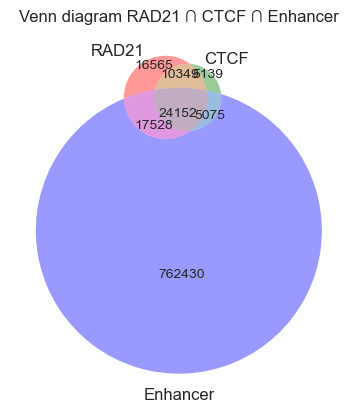

In [12]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Totali
rad21 = 68594
ctcf = 44715
enh = 809185

# Intersezioni
rad21_ctcf = 34501
rad21_enh = 41680
ctcf_enh = 29227
triple = 24152

# Calcolo delle sezioni uniche e doppie correggendo il triplo
rad21_only = rad21 - rad21_ctcf - rad21_enh + triple
ctcf_only = ctcf - rad21_ctcf - ctcf_enh + triple
enh_only = enh - rad21_enh - ctcf_enh + triple

rad21_ctcf_only = rad21_ctcf - triple
rad21_enh_only = rad21_enh - triple
ctcf_enh_only = ctcf_enh - triple

# Creazione Venn
venn3(
    subsets=(rad21_only, ctcf_only, rad21_ctcf_only,
             enh_only, rad21_enh_only, ctcf_enh_only,
             triple),
    set_labels=('RAD21', 'CTCF', 'Enhancer')
)

plt.title("Venn diagram RAD21 ∩ CTCF ∩ Enhancer")
plt.show()


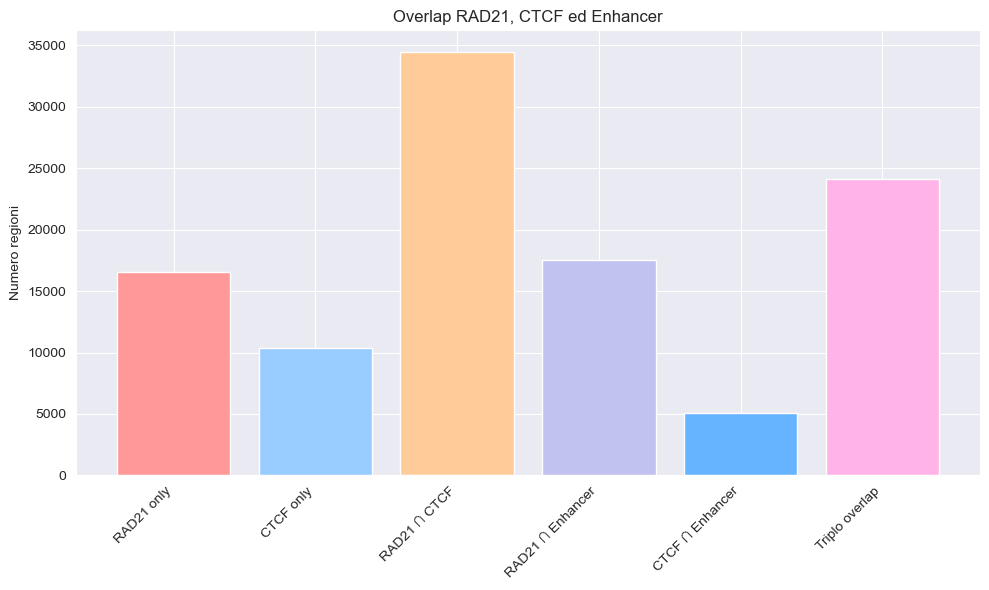

In [13]:
import matplotlib.pyplot as plt

# Dati
labels = [
    "RAD21 only",
    "CTCF only",
    "RAD21 ∩ CTCF",
    "RAD21 ∩ Enhancer",
    "CTCF ∩ Enhancer",
    "Triplo overlap"
]
values = [16565, 10349, 34501, 17528, 5075, 24152]

plt.figure(figsize=(10,6))
bars = plt.bar(labels, values, color=["#ff9999","#99ccff","#ffcc99","#c2c2f0","#66b3ff","#ffb3e6"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Numero regioni")
plt.title("Overlap RAD21, CTCF ed Enhancer")
plt.tight_layout()
plt.show()


Top 5 motivi significativi (RAD21-only):
            Target_ID  p-value  q-value  Overlap
GATA4_HUMAN.H11MO.0.A 0.000005 0.003654      6.0
 TAL1_HUMAN.H11MO.0.A 0.000013 0.003822      6.0
GATA6_HUMAN.H11MO.0.A 0.000014 0.003822      6.0
GATA3_HUMAN.H11MO.0.A 0.000027 0.005315      6.0
GATA1_HUMAN.H11MO.0.A 0.000041 0.006549      6.0


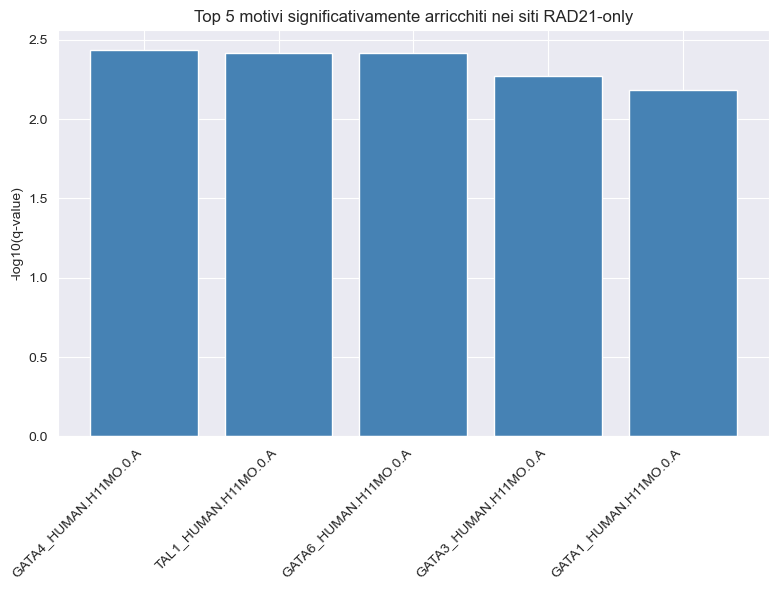

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carica il file TomTom RAD21-only
file_path = r"D:\SYSTEMS BIOLOGY\tomtomrad21only.tsv"
df = pd.read_csv(file_path, sep="\t")

# Filtra i match significativi (q-value < 0.05) e ordina
df_sig = df[df["q-value"] < 0.05].sort_values("q-value")

# Seleziona solo i primi 5
top5 = df_sig.head(5)[["Target_ID", "p-value", "q-value", "Overlap"]]

# Mostra la tabella
print("Top 5 motivi significativi (RAD21-only):")
print(top5.to_string(index=False))

# Crea il barplot
plt.figure(figsize=(8,6))
plt.bar(top5["Target_ID"], -np.log10(top5["q-value"]), color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("-log10(q-value)")
plt.title("Top 5 motivi significativamente arricchiti nei siti RAD21-only")
plt.tight_layout()
plt.show()


Top 5 motivi significativi (RAD21-only):
            Target_ID      p-value      q-value  Overlap
 CTCF_HUMAN.H11MO.0.A 9.895970e-21 7.857100e-18     15.0
CTCFL_HUMAN.H11MO.0.A 1.655910e-10 6.573720e-08     15.0
 CTCF_HUMAN.H11MO.0.A 5.337620e-07 4.221570e-04      7.0
ZN502_HUMAN.H11MO.0.C 2.480310e-06 1.976460e-03      8.0
SMCA5_HUMAN.H11MO.0.C 1.666890e-05 6.641380e-03      8.0


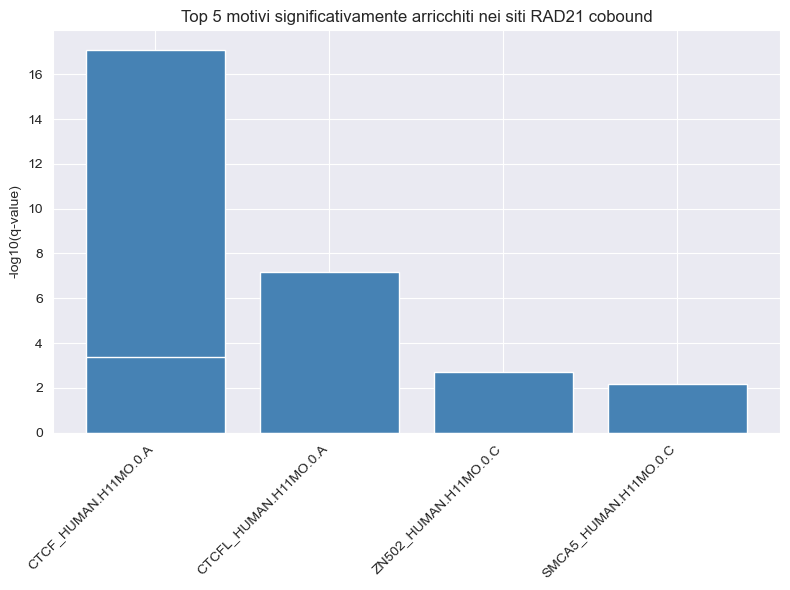

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carica il file TomTom RAD21-only
file_path = r"D:\SYSTEMS BIOLOGY\tomtomRAD21CTCF.tsv"
df = pd.read_csv(file_path, sep="\t")

# Filtra i match significativi (q-value < 0.05) e ordina
df_sig = df[df["q-value"] < 0.05].sort_values("q-value")

# Seleziona solo i primi 5
top5 = df_sig.head(5)[["Target_ID", "p-value", "q-value", "Overlap"]]

# Mostra la tabella
print("Top 5 motivi significativi (RAD21-only):")
print(top5.to_string(index=False))

# Crea il barplot
plt.figure(figsize=(8,6))
plt.bar(top5["Target_ID"], -np.log10(top5["q-value"]), color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("-log10(q-value)")
plt.title("Top 5 motivi significativamente arricchiti nei siti RAD21 cobound")
plt.tight_layout()
plt.show()
